In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from util import *
constituents = ["aapl", "nvda", "tsla", "msft", "amzn"]
df_ret = pd.read_csv("../data/close.csv.gz",names=constituents).pct_change().dropna()
year = "2024"

### Classical pareto fronts

In [2]:
# Random portfolios
weights = []
for i in range(1000):
    weights.append(random_portfolio())
weights = np.array(weights)

port_ret = df_ret @ (weights.T)
avg_ret_constant_booksize = port_ret.mean()
avg_ret_variable_booksize = np.exp(np.log(1+port_ret).mean())-1
port_std = port_ret.std()

Text(0, 0.5, 'Volatility Drag')

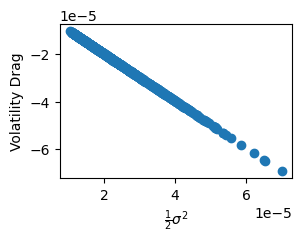

In [3]:
volatility_drag = avg_ret_variable_booksize - avg_ret_constant_booksize
plt.figure(figsize=(3,2))
plt.scatter(0.5 * port_std.pow(2).values, volatility_drag.values)
plt.xlabel("$\\frac{1}{2} \\sigma^2$")
plt.ylabel("Volatility Drag")

Text(0.5, 1.0, "Market participants' objective have\nVolatility risk regularization term")

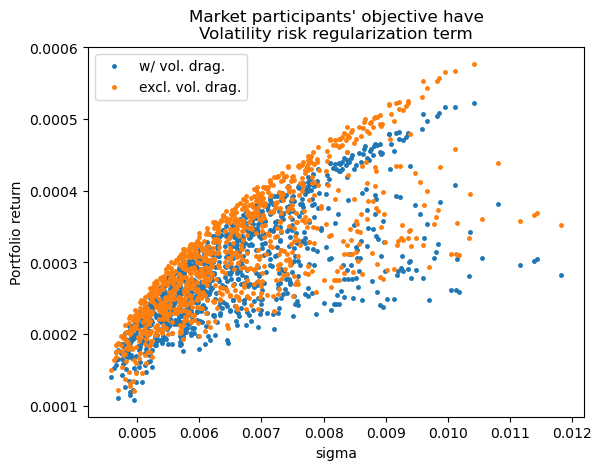

In [4]:
pd.DataFrame({
    "w/ vol. drag.": avg_ret_variable_booksize.values,
    "excl. vol. drag.": avg_ret_constant_booksize.values,
    "sigma": port_std
}).set_index("sigma").plot.line(lw=0, marker=".", ms=5, ylabel="Portfolio return")
plt.title("Market participants' objective have\nVolatility risk regularization term")

* One may use log-return reward, or r - 1/2 sigma reward for vol. drag risk-aware RL (Baumann et al. (2025))
* Or, volatility can be interpreteda as a risk, and regularization term can be added for portfolio optimization

### Complexity Pareto Front

In [5]:
import gzip
with gzip.open("../examples/behavior_1.txt.gz", "rt") as f :
    results = f.readlines()
results = [r for r in results[1:] if not r.startswith('Expression failed to terminate')]
results = [{x.split(":")[0].strip():x.split(":")[1].strip() for x in r.split('\t')} for r in results]
df_results = pd.DataFrame(results)
df_results["utility_traj"] = df_results["utility_traj"].apply(eval)
df_results["_utility"] = df_results["_utility"].astype(float).abs()
df_results["marginal_utility"] = df_results["marginal_utility"].astype(float).abs()
df_results["_marginal_utility"] = df_results["_marginal_utility"].astype(float).abs()
df_results["corr"] = df_results["corr"].astype(float).abs()
df_results["complexity_len"] = df_results["utility_traj"].apply(len)
df_results["complexity_huffman_log"] = df_results["Expr"].apply(huffman_complexity).apply(np.log)
df_results["complexity_gzip"] = df_results["Expr"].apply(gzip_complexity)

Text(0.5, 1.0, "Complexity is a risk\nIs it coming from traders' utility, or is it a overfit risk?\nWe can check OS/IS. Maybe ergodicity too?")

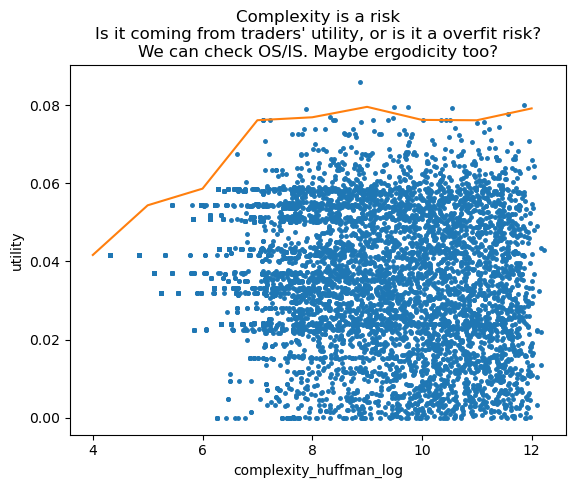

In [6]:
df_results.set_index(["complexity_huffman_log"])["_utility"].plot(lw=0, ms=5, marker=".")
df_results.groupby(df_results["complexity_huffman_log"].round(0))["_utility"].quantile(0.999).plot(ylabel="utility")
plt.title("Complexity is a risk\nIs it coming from traders' utility, or is it a overfit risk?\nWe can check OS/IS. Maybe ergodicity too?")

### Concentration Risk Pareto Front

* It seems that avg. pool correlation is not a good metric of concentration risk of a signal 
* Maybe we could do clustering, like HRP? 

<Axes: xlabel='corr'>

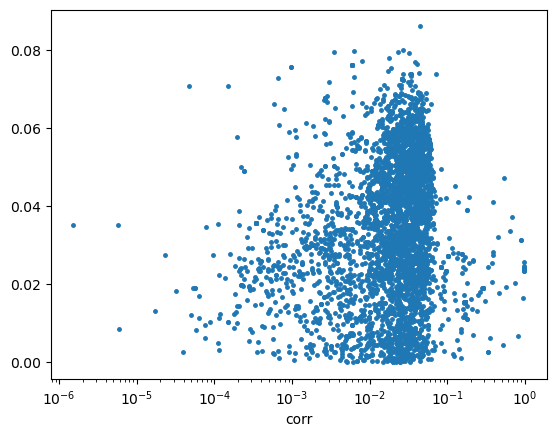

In [7]:
df_results.set_index(["corr"])["_utility"].plot(lw=0, ms=5, marker=".", logx=True)

### Nonergodic reward structure of SR

In [8]:
df = pd.Series(df_results["utility_traj"].loc[(df_results["utility_traj"].apply(len)>=20).values])
values = pd.DataFrame(df.apply(lambda x: x[:20]).tolist())
rewards = values.diff(axis=1).dropna(axis=1)

rewards_time_average = rewards.mean(axis=0)
rewards_ensemble_average = rewards.mean(axis=1)

(rewards_time_average.median(), rewards_ensemble_average.median())

(np.float64(-8.192552416169826e-05), np.float64(7.304098846218135e-19))

<Axes: ylabel='Frequency'>

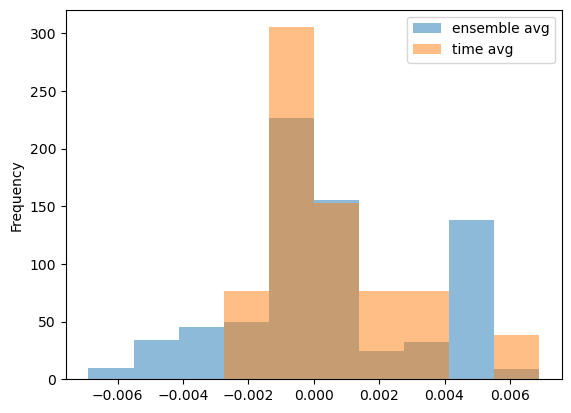

In [9]:
pd.DataFrame({
    "ensemble avg": rewards_ensemble_average,
    "time avg": rewards_time_average
}).plot.hist(density=True, alpha=0.5)